# Data Preperation

In [53]:
# Make sure to pip install openpyxl before reading excel files

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Orders

In [363]:
DATA_PATH = 'Muesli Project raw data.xlsx'
orders = pd.read_excel(DATA_PATH, sheet_name='Orders')

# rename columns in the dateset 
# get columns names from the first row 
col_names = list(orders.iloc[0])

# assign the columns names the right name
orders.columns = col_names
orders = orders[1:]

orders.sample(15)

,Index,Order ID,Order Date,Ship Mode,Customer ID,Customer Name,Origin Channel,Country/Region,City,State,Postal Code,Region,Category,Sub-Category,Product ID,Sales,Quantity,Discount,Profit
9846,7534,US-2020-134642,2020-02-25 00:00:00,Standard Class,SW-20245,Scot Wooten,Email,United States,Greenville,North Carolina,27834,South,Toasted Muesli,With Nuts,FUR-CH-10002880,196.78,2,0.20,-22.14
375,5029,CA-2017-151792,2017-09-02 00:00:00,Second Class,CV-12295,Christina VanderZanden,Email,United States,Chicago,Illinois,60653,Central,Special Projects Muesil,Gluten Free,TEC-AC-10001606,239.98,3,0.20,53.99
9909,8503,CA-2018-102316,2018-03-01 00:00:00,Second Class,DH-13075,Dave Hallsten,Sales,United States,Los Angeles,California,90045,West,Toasted Muesli,With Nuts,FUR-CH-10003396,184.75,3,0.20,-20.78
6452,5857,CA-2018-112214,2018-08-05 00:00:00,Standard Class,AH-10690,Anna Häberlin,Sales,United States,Dallas,Texas,75220,Central,Power Muesli,Super Fibre Boost,OFF-BI-10002982,1.36,1,0.80,-2.18
7443,4430,CA-2020-147725,2020-09-14 00:00:00,First Class,LT-17110,Liz Thompson,Email,United States,Orange,New Jersey,7050,East,Power Muesli,Super Mega Protein,OFF-AR-10001725,70.95,3,0,18.45
6544,6545,US-2020-154872,2020-05-14 00:00:00,Standard Class,DP-13000,Darren Powers,Email,United States,Cleveland,Ohio,44105,East,Power Muesli,Super Fibre Boost,OFF-BI-10003007,58.17,5,0.70,-46.54
8076,6625,CA-2018-141250,2018-01-19 00:00:00,Standard Class,PM-18940,Paul MacIntyre,Email,United States,Texas City,Texas,77590,Central,Toasted Muesli,Sweetened,FUR-TA-10002855,102.44,1,0.30,-13.17
5996,2971,CA-2020-167941,2020-11-06 00:00:00,Second Class,JF-15565,Jill Fjeld,Email,United States,Fayetteville,North Carolina,28314,South,Power Muesli,Super Fibre Boost,OFF-BI-10002827,13.27,8,0.70,-10.62
2333,1620,US-2019-118780,2019-09-10 00:00:00,Second Class,PN-18775,Parhena Norris,Facebook,United States,New York City,New York,10011,East,Power Muesli,Nuts and more,OFF-PA-10000575,6.69,1,0,3.08
3352,8947,CA-2020-148355,2020-12-24 00:00:00,Standard Class,NC-18535,Nick Crebassa,Sales,United States,New Bedford,Massachusetts,2740,East,Power Muesli,Nuts and more,OFF-PA-10001972,19.44,3,0,9.33


In [56]:
orders.shape

(9994, 19)

In [57]:
# Droping Excel Index Column 
orders.drop(columns='Index', inplace=True)

In [58]:
orders.duplicated().sum()

1

In [59]:
orders.isna().sum() # We have 11 NA's in orders in Postal Code. We do not need this column for now so I will just ignore it for now.

Order ID           0
Order Date         0
Ship Mode          0
Customer ID        0
Customer Name      0
Origin Channel     0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Category           0
Sub-Category       0
Product ID         0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

All features in the dataset are objects. <br> Data types should be reformated.

In [60]:
# TODO: Convert dates to date data-type 
orders['Order Date'] = orders['Order Date'].astype('datetime64[ns]')

In [61]:
# TODO: Convert numbers in sales, quantity discount and profit 
orders['Sales'] = orders['Sales'].astype(float)
orders['Quantity'] = orders['Quantity'].astype(int)
orders['Discount'] = orders['Discount'].astype(float)
orders['Profit'] = orders['Profit'].astype(float)

In [62]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 1 to 9994
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        9994 non-null   object        
 1   Order Date      9994 non-null   datetime64[ns]
 2   Ship Mode       9994 non-null   object        
 3   Customer ID     9994 non-null   object        
 4   Customer Name   9994 non-null   object        
 5   Origin Channel  9994 non-null   object        
 6   Country/Region  9994 non-null   object        
 7   City            9994 non-null   object        
 8   State           9994 non-null   object        
 9   Postal Code     9983 non-null   object        
 10  Region          9994 non-null   object        
 11  Category        9994 non-null   object        
 12  Sub-Category    9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Sales           9994 non-null   float64       
 15  Quan

In [63]:
orders.drop_duplicates(inplace=True)
orders.duplicated().value_counts()

False    9993
Name: count, dtype: int64

In [64]:
orders.describe()

,Order Date,Sales,Quantity,Discount,Profit
count,9993,"9,993.00","9,993.00","9,993.00","9,993.00"
mean,2019-04-30 19:27:38.961273088,229.85,3.79,0.16,28.66
min,2017-01-03 00:00:00,0.44,1.00,0.00,"-6,599.98"
25%,2018-05-23 00:00:00,17.28,2.00,0.00,1.73
50%,2019-06-26 00:00:00,54.48,3.00,0.20,8.67
75%,2020-05-14 00:00:00,209.94,5.00,0.20,29.36
max,2020-12-30 00:00:00,"22,638.48",14.00,0.80,"8,399.98"
std,NaN,623.28,2.23,0.21,234.27


## Campagin data

In [65]:
campaign_data = pd.read_excel(DATA_PATH, sheet_name='Campaign Data')

In [66]:
campaign_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order ID           333 non-null    object        
 1   Arrival Scan Date  333 non-null    datetime64[ns]
 2   Customer Name      333 non-null    object        
dtypes: datetime64[ns](1), object(2)
memory usage: 7.9+ KB


We have 333 customers who scaned the orders when arrived.

In [67]:
campaign_data.duplicated().sum()

0

In [68]:
campaign_data.isna().sum()

Order ID             0
Arrival Scan Date    0
Customer Name        0
dtype: int64

In [69]:
campaign_data.describe()

,Arrival Scan Date
count,333
mean,2019-10-14 19:36:12.972973056
min,2019-05-03 00:00:00
25%,2019-09-09 00:00:00
50%,2019-10-21 00:00:00
75%,2019-12-16 00:00:00
max,2020-05-15 00:00:00


## Order process data

In [70]:
order_process = pd.read_excel(DATA_PATH, sheet_name='Order Process Data')
order_process.head(5)

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


In [71]:
order_process.duplicated().value_counts()

False    5899
Name: count, dtype: int64

In [72]:
order_process.isna().sum()

Row ID                0
Order ID              0
Order Date            0
On Truck Scan Date    0
Ship Mode             0
dtype: int64

In [73]:
order_process.describe()

,Row ID,Order Date,On Truck Scan Date
count,"5,899.00",5899,5899
mean,"5,022.43",2020-02-29 02:22:48.231903744,2020-03-06 05:16:21.929140480
min,1.00,2019-01-02 00:00:00,2019-01-07 00:00:00
25%,"2,485.50",2019-09-11 00:00:00,2019-09-18 00:00:00
50%,"5,091.00",2020-03-16 00:00:00,2020-03-20 00:00:00
75%,"7,460.00",2020-09-13 12:00:00,2020-09-18 00:00:00
max,"9,994.00",2020-12-30 00:00:00,2021-01-06 00:00:00
std,"2,878.46",NaN,NaN


## Intern Data

In [74]:
intern_data = pd.read_excel(DATA_PATH, sheet_name='InternData Study')
intern_data.head(5)
intern_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Order ID            290 non-null    object        
 1   Ready to Ship Date  290 non-null    datetime64[ns]
 2   Pickup Date         290 non-null    datetime64[ns]
dtypes: datetime64[ns](2), object(1)
memory usage: 6.9+ KB


In the intern dataset there is 86 duplicated values.
We need here to add other indicators and understand why is there so many duplicts and improve the data quality for each scan.

In [75]:
print(intern_data['Order ID'].duplicated().value_counts(), '\n')
print(intern_data['Ready to Ship Date'].duplicated().value_counts()) # make sense because on the same day there is many orders
intern_data['Pickup Date'].duplicated().value_counts() # make sense because on the same day there is pickups

Order ID
False    204
True      86
Name: count, dtype: int64 

Ready to Ship Date
True     247
False     43
Name: count, dtype: int64


Pickup Date
True     260
False     30
Name: count, dtype: int64

In [76]:
intern_data.drop_duplicates(inplace=True)

In [77]:
intern_data.isna().sum()

Order ID              0
Ready to Ship Date    0
Pickup Date           0
dtype: int64

In [78]:
intern_data.describe()

,Ready to Ship Date,Pickup Date
count,204,204
mean,2020-07-07 01:03:31.764705792,2020-07-08 14:49:24.705882368
min,2019-09-02 00:00:00,2019-09-03 00:00:00
25%,2019-09-24 00:00:00,2019-09-25 00:00:00
50%,2020-11-12 00:00:00,2020-11-13 00:00:00
75%,2020-11-23 00:00:00,2020-11-25 00:00:00
max,2020-12-07 00:00:00,2020-12-09 00:00:00


## Processing Time

In [79]:
# in the warehause -> on truck scan - order date 
order_process.info()
order_process['total_time_in_warehause'] = order_process['On Truck Scan Date'] - order_process['Order Date']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Row ID              5899 non-null   int64         
 1   Order ID            5899 non-null   object        
 2   Order Date          5899 non-null   datetime64[ns]
 3   On Truck Scan Date  5899 non-null   datetime64[ns]
 4   Ship Mode           5899 non-null   object        
dtypes: datetime64[ns](2), int64(1), object(2)
memory usage: 230.6+ KB


In [80]:
print(intern_data.head())
order_process.head()

         Order ID Ready to Ship Date Pickup Date
0  CA-2019-116540         2019-09-02  2019-09-03
2  CA-2019-129847         2019-09-04  2019-09-04
3  CA-2019-129630         2019-09-04  2019-09-04
4  CA-2019-106278         2019-09-05  2019-09-06
5  CA-2019-158099         2019-09-05  2019-09-06


,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode,total_time_in_warehause
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express,4 days
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing,7 days
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing,7 days
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing,6 days
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing,6 days


In [81]:
processing_df = pd.merge(left=order_process, right=intern_data, how='inner' ,on='Order ID')

In [82]:
processing_df['processing_time'] = processing_df['Ready to Ship Date'] - processing_df['Order Date']

In [83]:
plt.style.use('fivethirtyeight') 
pd.options.display.float_format = "{:,.2f}".format

total_warehause_hist_x = processing_df['total_time_in_warehause'].dt.days
processing_hist_x = processing_df['processing_time'].dt.days
print("Total time spend in warehouse before shipping",total_warehause_hist_x.describe(), "\n")
print("Processing Time",processing_hist_x.describe())

Total time spend in warehouse before shipping count   418.00
mean      5.80
std       2.55
min       0.00
25%       4.00
50%       7.00
75%       8.00
max      10.00
Name: total_time_in_warehause, dtype: float64 

Processing Time count   418.00
mean      4.16
std       1.95
min       0.00
25%       3.00
50%       5.00
75%       6.00
max       8.00
Name: processing_time, dtype: float64


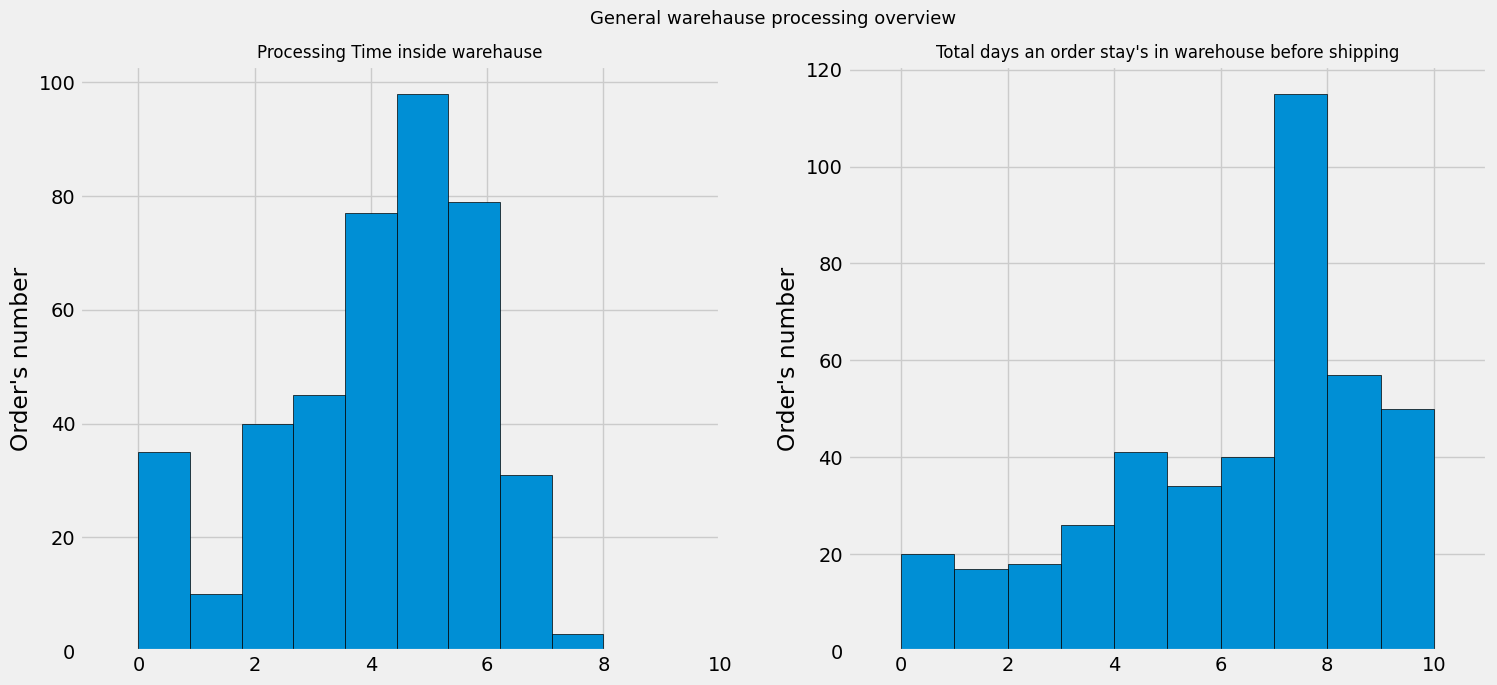

In [338]:

fig, ax = plt.subplots(1,2, figsize=(15,7))
plt.suptitle('General warehause processing overview', fontsize=13)
fig.tight_layout()
plt.subplots_adjust(hspace = .5, wspace = .2, top = .9)

ax[1].hist(x=total_warehause_hist_x, bins=10, edgecolor='black')
ax[1].set_ylabel('Order\'s number')
ax[1].set_xlim(-1,11)
ax[1].set_title('Total days an order stay\'s in warehouse before shipping', fontsize = 12)

ax[0].hist(x=processing_hist_x, bins=9, edgecolor='black')
ax[0].set_ylabel('Order\'s number')
ax[0].set_xlim(-1,10)
ax[0].set_title('Processing Time inside warehause', fontsize = 12);

## Prodcut Shiping mode difference

In [85]:
processing_df['Ship Mode'].value_counts()

Ship Mode
Standard Processing    316
Express                102
Name: count, dtype: int64

In [86]:
express_orders = processing_df[processing_df['Ship Mode'] == 'Express']
express_whtd = express_orders['total_time_in_warehause'].dt.days
express_pt = express_orders['processing_time'].dt.days

standard_orders = processing_df[processing_df['Ship Mode'] == 'Standard Processing']
standard_whtd = standard_orders['total_time_in_warehause'].dt.days
standard_pt = standard_orders['processing_time'].dt.days

print(express_orders['Ship Mode'].describe(),'\n')
print(standard_orders['Ship Mode'].describe())

count         102
unique          1
top       Express
freq          102
Name: Ship Mode, dtype: object 

count                     316
unique                      1
top       Standard Processing
freq                      316
Name: Ship Mode, dtype: object


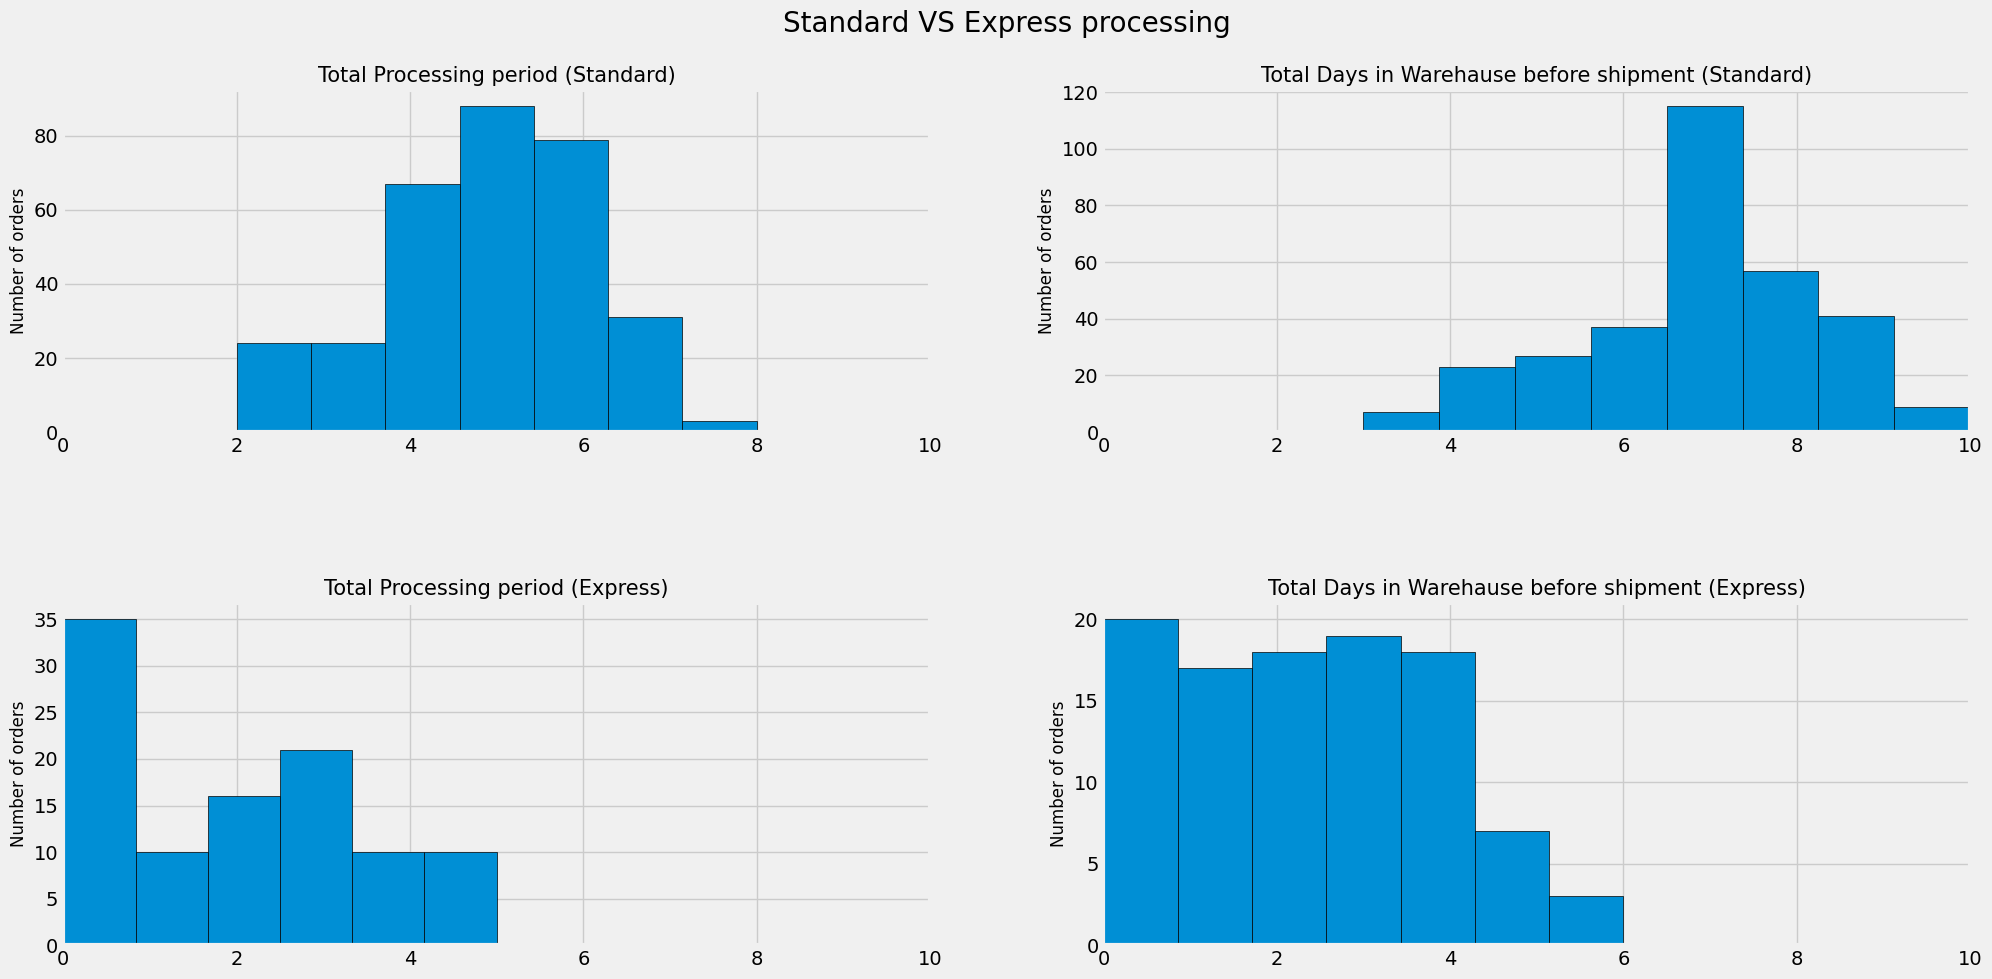

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(20,10))
plt.suptitle('Standard VS Express processing', fontsize=20)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0][0].hist(x=standard_pt, bins=7, edgecolor='black')
ax[0][0].set_ylabel('Number of orders', fontsize=12)
ax[0][0].set_xlim(0,10)
ax[0][0].set_title('Total Processing period (Standard)', fontsize=15)

ax[0][1].hist(x=standard_whtd, bins=8, edgecolor='black')
ax[0][1].set_ylabel('Number of orders', fontsize=12)
ax[0][1].set_xlim(0,10)
ax[0][1].set_title('Total Days in Warehause before shipment (Standard)', fontsize=15)


ax[1][0].hist(x=express_pt, bins=6, edgecolor='black')
ax[1][0].set_ylabel('Number of orders', fontsize=12)
ax[1][0].set_xlim(0,10)
ax[1][0].set_title('Total Processing period (Express)', fontsize=15)

ax[1][1].hist(x=express_whtd, bins=7, edgecolor='black')
ax[1][1].set_ylabel('Number of orders', fontsize=12)
ax[1][1].set_xlim(0,10)
ax[1][1].set_title('Total Days in Warehause before shipment (Express)', fontsize=15);

In [343]:
express_pt.describe()


count   102.00
mean      1.91
std       1.72
min       0.00
25%       0.00
50%       2.00
75%       3.00
max       5.00
Name: processing_time, dtype: float64

## Order's waiting for truck time

In [92]:
processing_df['waiting_for_truck'] = processing_df['On Truck Scan Date'] - processing_df['Ready to Ship Date']
processing_df['waiting_for_truck'].describe()

count                          418
mean     1 days 15:26:41.913875598
std      0 days 23:12:24.026769113
min                0 days 00:00:00
25%                1 days 00:00:00
50%                2 days 00:00:00
75%                2 days 00:00:00
max                3 days 00:00:00
Name: waiting_for_truck, dtype: object

## Express VS Standard

In [93]:
processing_df.head()

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode,total_time_in_warehause,Ready to Ship Date,Pickup Date,processing_time,waiting_for_truck
0,3416,CA-2019-116540,2019-09-02,2019-09-03,Express,1 days,2019-09-02,2019-09-03,0 days,1 days
1,3417,CA-2019-116540,2019-09-02,2019-09-03,Express,1 days,2019-09-02,2019-09-03,0 days,1 days
2,6937,CA-2019-129847,2019-09-02,2019-09-04,Express,2 days,2019-09-04,2019-09-04,2 days,0 days
3,9929,CA-2019-129630,2019-09-04,2019-09-04,Express,0 days,2019-09-04,2019-09-04,0 days,0 days
4,9930,CA-2019-129630,2019-09-04,2019-09-04,Express,0 days,2019-09-04,2019-09-04,0 days,0 days


In [ ]:
express_orders  = processing_df[processing_df['Ship Mode'] == 'Express']
standard_orders = processing_df[processing_df['Ship Mode'] == 'Standard Processing']


print('Express orders waiting for truck loading' , express_orders['waiting_for_truck'].describe(), '\n')
print('Standard orders waiting for truck loading', standard_orders['waiting_for_truck'].describe())


Express orders waiting for truck loading count                          102
mean     0 days 09:24:42.352941176
std      0 days 12:15:00.572304417
min                0 days 00:00:00
25%                0 days 00:00:00
50%                0 days 00:00:00
75%                1 days 00:00:00
max                2 days 00:00:00
Name: waiting_for_truck, dtype: object 

Standard orders waiting for truck loading count                          316
mean     2 days 01:08:21.265822784
std      0 days 16:41:14.653015232
min                1 days 00:00:00
25%                2 days 00:00:00
50%                2 days 00:00:00
75%                3 days 00:00:00
max                3 days 00:00:00
Name: waiting_for_truck, dtype: object


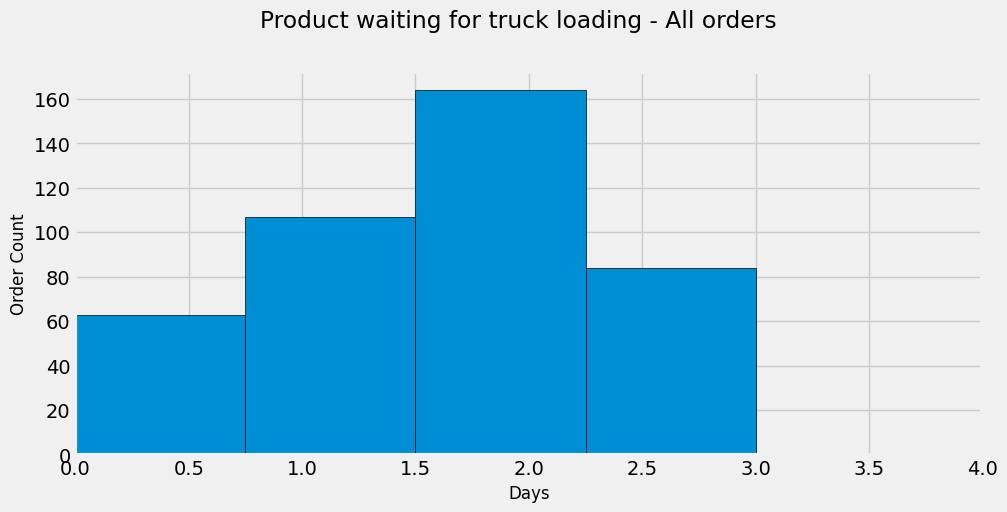

In [141]:
hist_x_axes_all = processing_df['waiting_for_truck'].dt.days
fig, ax = plt.subplots(figsize=(10,5))
plt.suptitle('Product waiting for truck loading - All orders')
fig.tight_layout()

ax.hist(x=hist_x_axes_all, bins=4, edgecolor='black')
ax.set_ylabel('Order Count', fontsize=12)
ax.set_xlabel('Days', fontsize=12)
ax.set_xlim(0,4);

In [ ]:
# Express VS Standard waiting for truck 
standard_wft = standard_orders['waiting_for_truck'].dt.days
express_wft = express_orders['waiting_for_truck'].dt.days

In [346]:
express_wft.describe()

count   102.00
mean      0.39
std       0.51
min       0.00
25%       0.00
50%       0.00
75%       1.00
max       2.00
Name: waiting_for_truck, dtype: float64

Text(0.5, 1.0, 'Product waiting for truck (Express)')

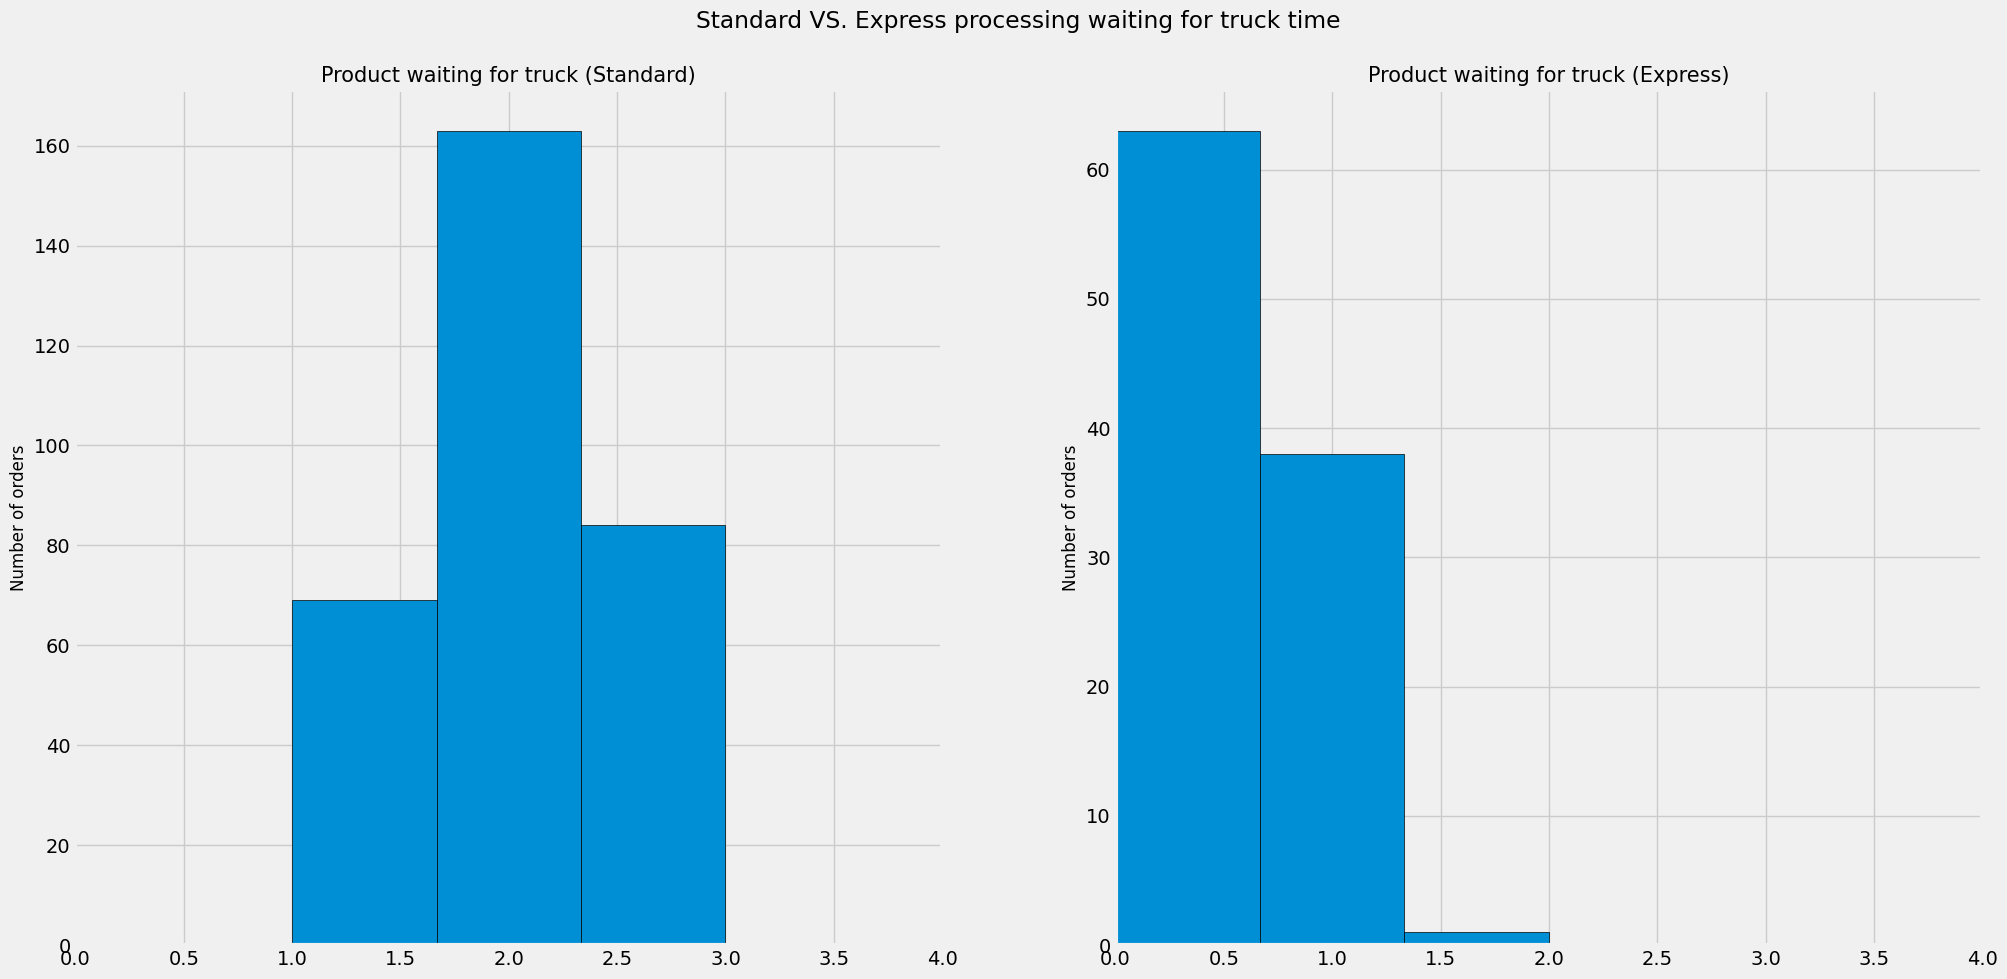

In [345]:
fig, ax = plt.subplots(1,2, figsize=(20,10))
plt.suptitle('Standard VS. Express processing waiting for truck time')
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0].hist(x=standard_wft, bins=3, edgecolor='black')
ax[0].set_ylabel('Number of orders', fontsize=12)
ax[0].set_xlim(0,4)
ax[0].set_title('Product waiting for truck (Standard)', fontsize=15)

ax[1].hist(x=express_wft, bins=3, edgecolor='black')
ax[1].set_ylabel('Number of orders', fontsize=12)
ax[1].set_xlim(0,4)
ax[1].set_title('Product waiting for truck (Express)', fontsize=15)

In [204]:
processing_df['order_day'] = processing_df['Order Date'].dt.day_name()

weekend_orders = processing_df[(processing_df['order_day'] == 'Sunday') | (processing_df['order_day'] == 'Saturday')]
weekday_orders = processing_df[(processing_df['order_day'] != 'Sunday') & (processing_df['order_day'] != 'Saturday')]

#weekend_orders
#weekday_order

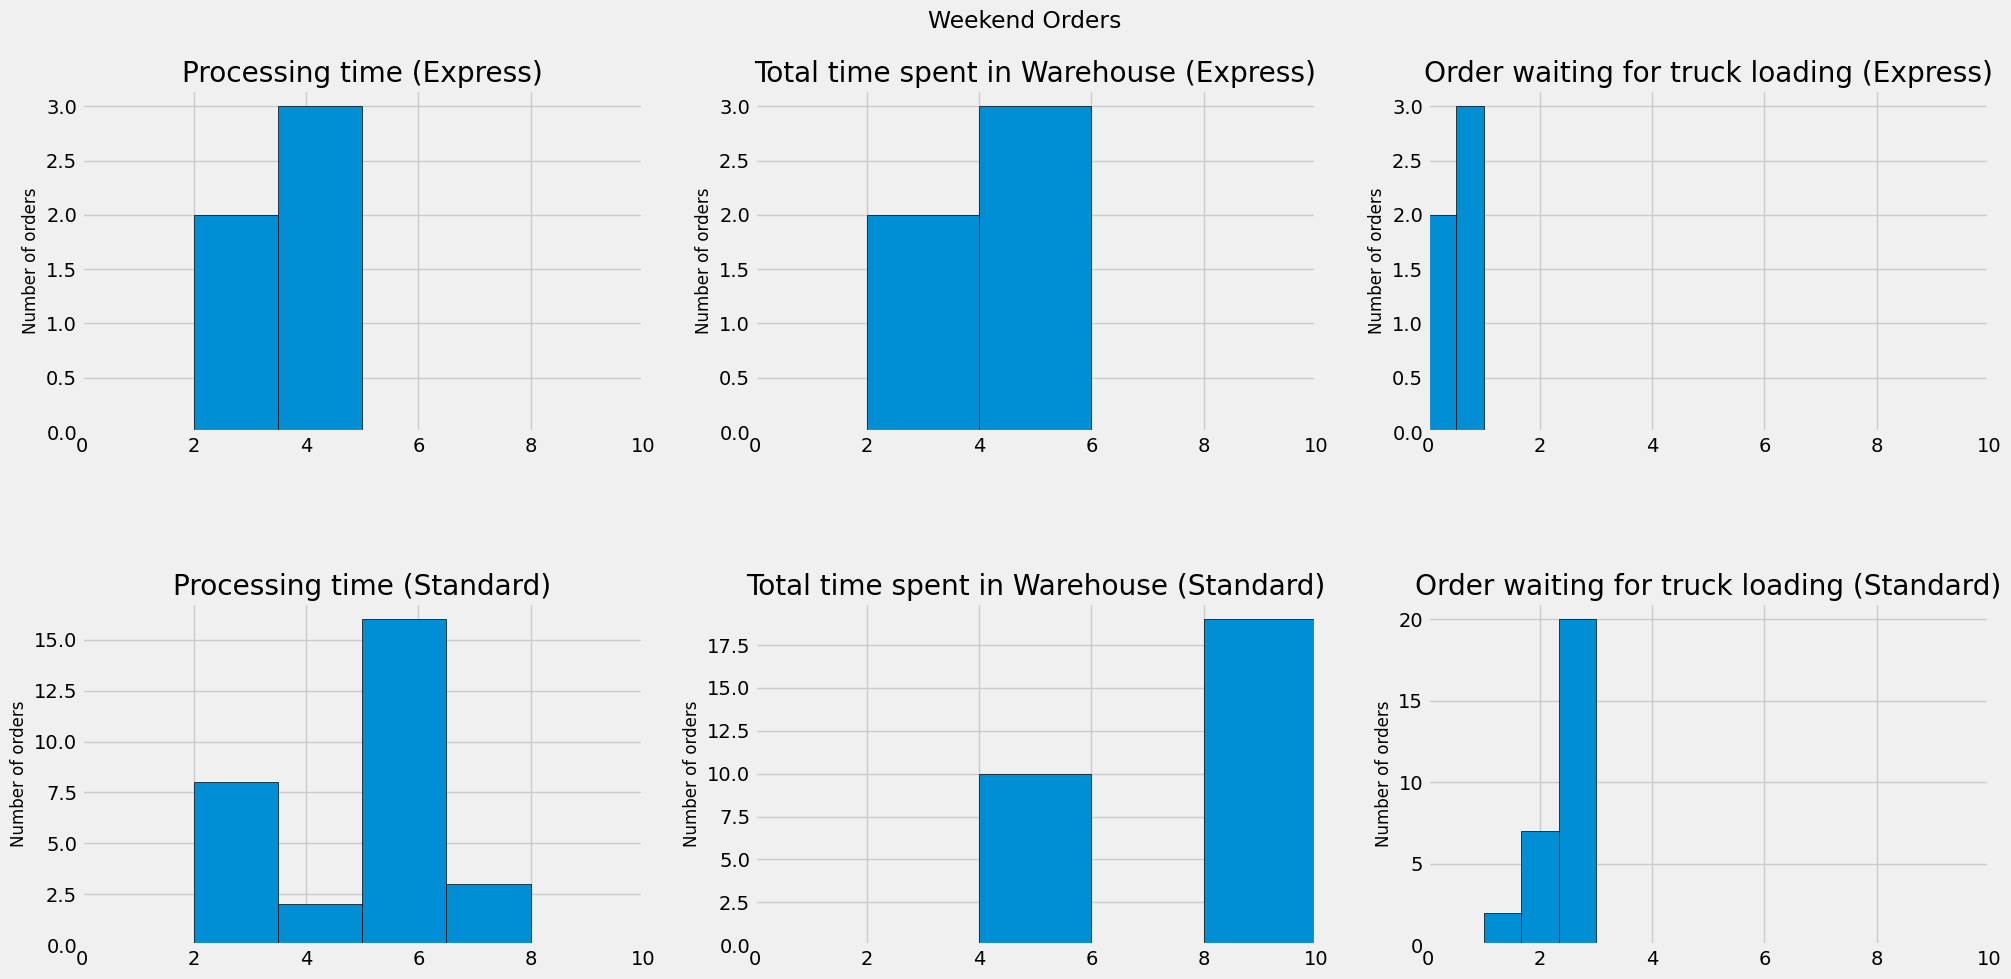

In [245]:

#### Weekend
# Standard -> total time in warehouse
# Standard -> total processiing time 
# Standard -> waiting for truck

# Express -> total time in warehouse
# Express -> total processiing time 
# Express -> waiting for truck
weekend_orders_express = weekend_orders[weekend_orders['Ship Mode'] == 'Express']
we_ex_tiwh = weekend_orders_express['total_time_in_warehause'].dt.days
we_ex_pt = weekend_orders_express['processing_time'].dt.days 
we_ex_wt = weekend_orders_express['waiting_for_truck'].dt.days 

weekend_orders_standard = weekend_orders[weekend_orders['Ship Mode'] == 'Standard Processing']
we_st_tiwh = weekend_orders_standard['total_time_in_warehause'].dt.days
we_st_pt = weekend_orders_standard['processing_time'].dt.days 
we_st_wt = weekend_orders_standard['waiting_for_truck'].dt.days 


fig, ax = plt.subplots(2,3, figsize=(20,10))
plt.suptitle('Weekend Orders')
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0][0].hist(x=we_ex_pt, bins=2, edgecolor='black')
ax[0][0].set_ylabel('Number of orders', fontsize=12)
ax[0][0].set_xlim(0,10)
ax[0][0].set_title('Processing time (Express)')

ax[0][1].hist(x=we_ex_tiwh, bins=2, edgecolor='black')
ax[0][1].set_ylabel('Number of orders', fontsize=12)
ax[0][1].set_xlim(0,10)
ax[0][1].set_title('Total time spent in Warehouse (Express)')

ax[0][2].hist(x=we_ex_wt, bins=2, edgecolor='black')
ax[0][2].set_ylabel('Number of orders', fontsize=12)
ax[0][2].set_xlim(0,10)
ax[0][2].set_title('Order waiting for truck loading (Express)')

ax[1][0].hist(x=we_st_pt, bins=4, edgecolor='black')
ax[1][0].set_ylabel('Number of orders', fontsize=12)
ax[1][0].set_xlim(0,10)
ax[1][0].set_title('Processing time (Standard)')

ax[1][1].hist(x=we_st_tiwh, bins=3, edgecolor='black')
ax[1][1].set_ylabel('Number of orders', fontsize=12)
ax[1][1].set_xlim(0,10)
ax[1][1].set_title('Total time spent in Warehouse (Standard)')

ax[1][2].hist(x=we_st_wt, bins=3, edgecolor='black')
ax[1][2].set_ylabel('Number of orders', fontsize=12)
ax[1][2].set_xlim(0,10)
ax[1][2].set_title('Order waiting for truck loading (Standard)')



### Weekday
# Standard -> total time in warehouse  
# Standard -> total processiing time
# Standard -> waiting for truck

# Express -> total time in warehouse  
# Express -> total processiing time
# Express -> waiting for truck

weekday_orders_express = weekday_orders[weekday_orders['Ship Mode'] == 'Express']
weekday_orders_standard = weekday_orders[weekday_orders['Ship Mode'] == 'Standard Processing']

In [ ]:
we_ex_tiwh 
we_ex_pt 
we_ex_wt 

we_st_tiwh 
we_st_pt 
we_st_wt

In [354]:
we_st_pt.describe()

count   29.00
mean     4.97
std      2.04
min      2.00
25%      2.00
50%      6.00
75%      6.00
max      8.00
Name: processing_time, dtype: float64

In [352]:
we_st_tiwh.describe()

count   29.00
mean     7.59
std      2.24
min      4.00
25%      5.00
50%      9.00
75%      9.00
max     10.00
Name: total_time_in_warehause, dtype: float64

In [353]:
we_st_wt.describe()

count   29.00
mean     2.62
std      0.62
min      1.00
25%      2.00
50%      3.00
75%      3.00
max      3.00
Name: waiting_for_truck, dtype: float64

In [220]:
weekend_orders_express.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5 entries, 154 to 337
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   Row ID                   5 non-null      int64          
 1   Order ID                 5 non-null      object         
 2   Order Date               5 non-null      datetime64[ns] 
 3   On Truck Scan Date       5 non-null      datetime64[ns] 
 4   Ship Mode                5 non-null      object         
 5   total_time_in_warehause  5 non-null      timedelta64[ns]
 6   Ready to Ship Date       5 non-null      datetime64[ns] 
 7   Pickup Date              5 non-null      datetime64[ns] 
 8   processing_time          5 non-null      timedelta64[ns]
 9   waiting_for_truck        5 non-null      timedelta64[ns]
 10  order_day                5 non-null      object         
dtypes: datetime64[ns](4), int64(1), object(3), timedelta64[ns](3)
memory usage: 480.0+ bytes


In [213]:
weekend_orders_express.describe()

,Row ID,Order Date,On Truck Scan Date,total_time_in_warehause,Ready to Ship Date,Pickup Date,processing_time,waiting_for_truck
count,5.00,5,5,5,5,5,5,5
mean,"7,154.60",2020-11-16 19:12:00,2020-11-21 04:48:00,4 days 09:36:00,2020-11-20 14:24:00,2020-11-21 04:48:00,3 days 19:12:00,0 days 14:24:00
min,"4,011.00",2020-11-07 00:00:00,2020-11-09 00:00:00,2 days 00:00:00,2020-11-09 00:00:00,2020-11-09 00:00:00,2 days 00:00:00,0 days 00:00:00
25%,"4,012.00",2020-11-14 00:00:00,2020-11-20 00:00:00,2 days 00:00:00,2020-11-19 00:00:00,2020-11-20 00:00:00,2 days 00:00:00,0 days 00:00:00
50%,"9,039.00",2020-11-21 00:00:00,2020-11-23 00:00:00,6 days 00:00:00,2020-11-23 00:00:00,2020-11-23 00:00:00,5 days 00:00:00,1 days 00:00:00
75%,"9,218.00",2020-11-21 00:00:00,2020-11-27 00:00:00,6 days 00:00:00,2020-11-26 00:00:00,2020-11-27 00:00:00,5 days 00:00:00,1 days 00:00:00
max,"9,493.00",2020-11-21 00:00:00,2020-11-27 00:00:00,6 days 00:00:00,2020-11-26 00:00:00,2020-11-27 00:00:00,5 days 00:00:00,1 days 00:00:00
std,"2,873.80",NaN,NaN,2 days 04:34:52.915873785,NaN,NaN,1 days 15:26:09.686905339,0 days 13:08:43.228968446


In [212]:
weekend_orders_standard.describe()

,Row ID,Order Date,On Truck Scan Date,total_time_in_warehause,Ready to Ship Date,Pickup Date,processing_time,waiting_for_truck
count,29.00,29,29,29,29,29,29,29
mean,"3,709.69",2020-11-18 12:24:49.655172352,2020-11-26 02:28:57.931034368,7 days 14:04:08.275862069,2020-11-23 11:35:10.344827648,2020-11-26 02:28:57.931034368,4 days 23:10:20.689655172,2 days 14:53:47.586206896
min,948.00,2020-11-01 00:00:00,2020-11-06 00:00:00,4 days 00:00:00,2020-11-05 00:00:00,2020-11-06 00:00:00,2 days 00:00:00,1 days 00:00:00
25%,"2,075.00",2020-11-14 00:00:00,2020-11-18 00:00:00,5 days 00:00:00,2020-11-16 00:00:00,2020-11-18 00:00:00,2 days 00:00:00,2 days 00:00:00
50%,"3,559.00",2020-11-21 00:00:00,2020-11-30 00:00:00,9 days 00:00:00,2020-11-27 00:00:00,2020-11-30 00:00:00,6 days 00:00:00,3 days 00:00:00
75%,"6,147.00",2020-11-28 00:00:00,2020-12-02 00:00:00,9 days 00:00:00,2020-11-30 00:00:00,2020-12-02 00:00:00,6 days 00:00:00,3 days 00:00:00
max,"8,432.00",2020-11-28 00:00:00,2020-12-07 00:00:00,10 days 00:00:00,2020-12-04 00:00:00,2020-12-07 00:00:00,8 days 00:00:00,3 days 00:00:00
std,"2,399.80",NaN,NaN,2 days 05:51:48.738881924,NaN,NaN,2 days 01:03:09.000990820,0 days 14:55:27.984837324


Text(0.5, 1.0, 'Order waiting for truck loading (Standard)')

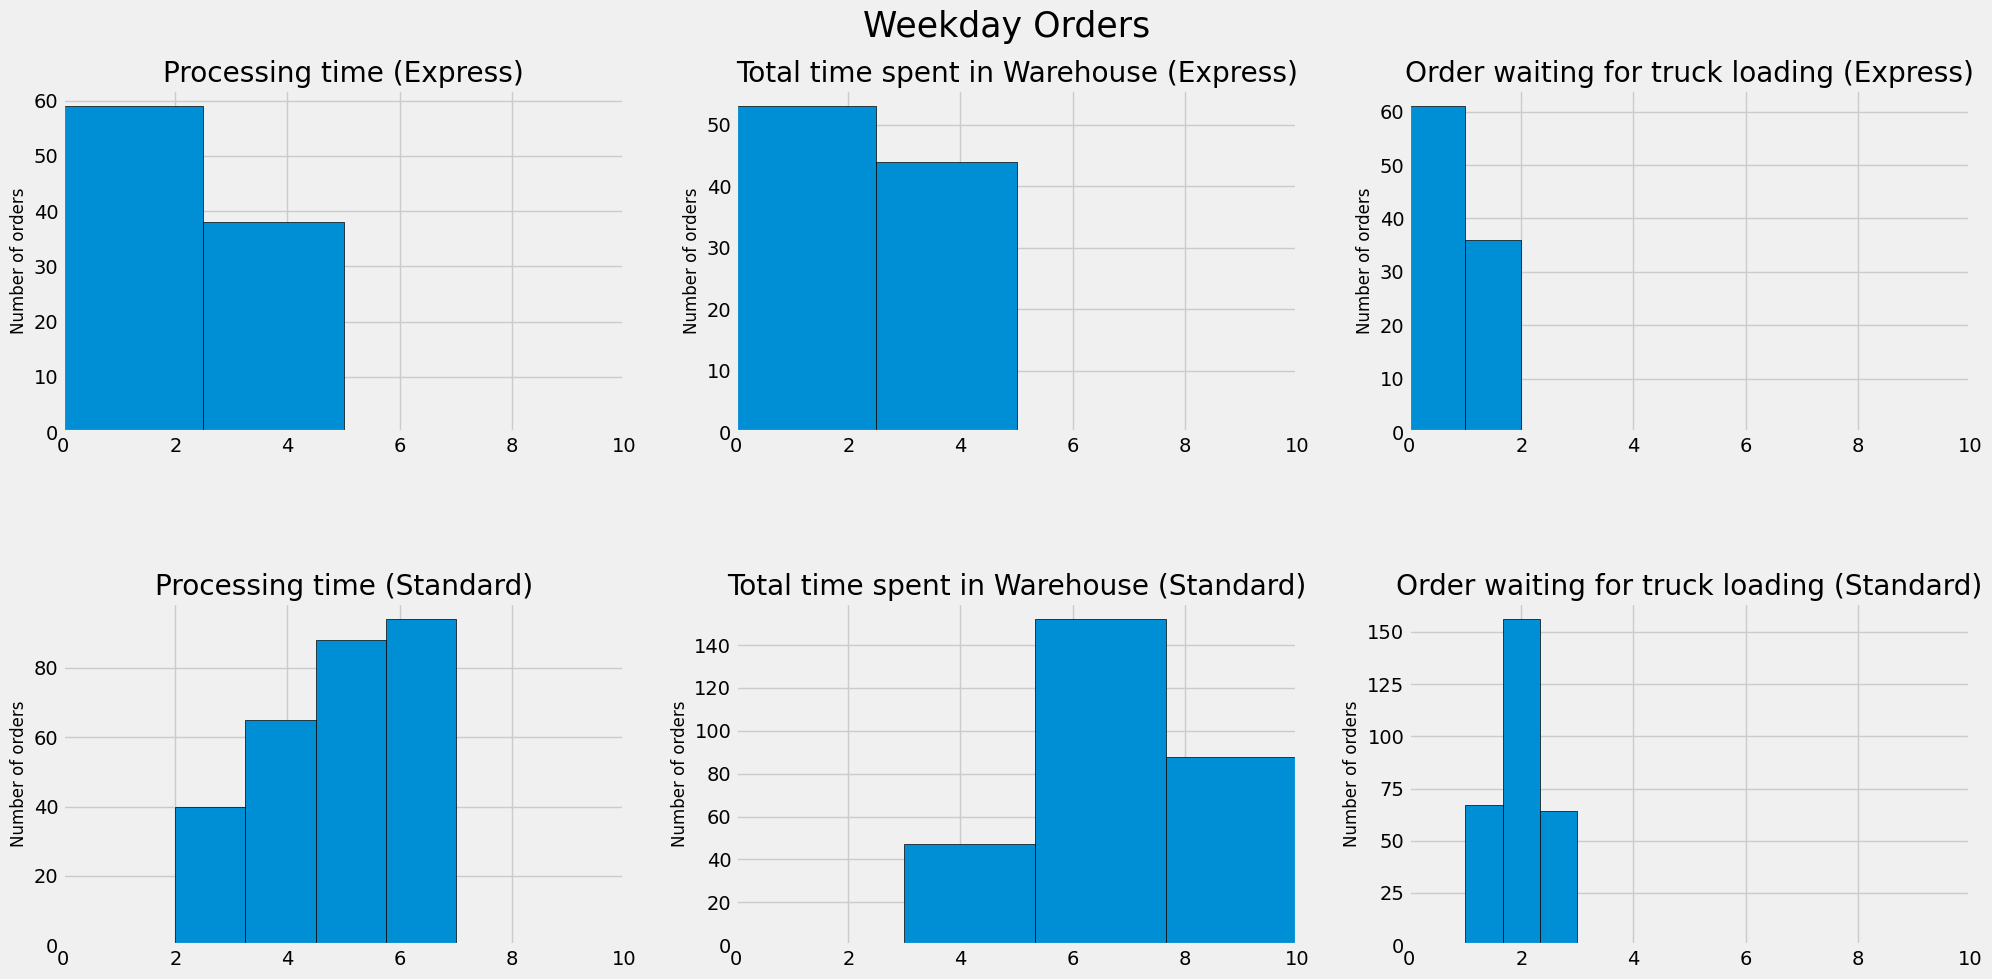

In [266]:
weekday_orders_express = weekday_orders[weekday_orders['Ship Mode'] == 'Express']
wd_ex_tiwh = weekday_orders_express['total_time_in_warehause'].dt.days
wd_ex_pt = weekday_orders_express['processing_time'].dt.days 
wd_ex_wt = weekday_orders_express['waiting_for_truck'].dt.days 

weekday_orders_standard = weekday_orders[weekday_orders['Ship Mode'] == 'Standard Processing']
wd_st_tiwh = weekday_orders_standard['total_time_in_warehause'].dt.days
wd_st_pt = weekday_orders_standard['processing_time'].dt.days 
wd_st_wt = weekday_orders_standard['waiting_for_truck'].dt.days 


fig, ax = plt.subplots(2,3, figsize=(20,10))
plt.suptitle('Weekday Orders', fontsize=25)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

ax[0][0].hist(x=wd_ex_pt, bins=2, edgecolor='black')
ax[0][0].set_ylabel('Number of orders', fontsize=12)
ax[0][0].set_xlim(0,10)
ax[0][0].set_title('Processing time (Express)')

ax[0][1].hist(x=wd_ex_tiwh, bins=2, edgecolor='black')
ax[0][1].set_ylabel('Number of orders', fontsize=12)
ax[0][1].set_xlim(0,10)
ax[0][1].set_title('Total time spent in Warehouse (Express)')

ax[0][2].hist(x=wd_ex_wt, bins=2, edgecolor='black')
ax[0][2].set_ylabel('Number of orders', fontsize=12)
ax[0][2].set_xlim(0,10)
ax[0][2].set_title('Order waiting for truck loading (Express)')

ax[1][0].hist(x=wd_st_pt, bins=4, edgecolor='black')
ax[1][0].set_ylabel('Number of orders', fontsize=12)
ax[1][0].set_xlim(0,10)
ax[1][0].set_title('Processing time (Standard)')

ax[1][1].hist(x=wd_st_tiwh, bins=3, edgecolor='black')
ax[1][1].set_ylabel('Number of orders', fontsize=12)
ax[1][1].set_xlim(0,10)
ax[1][1].set_title('Total time spent in Warehouse (Standard)')

ax[1][2].hist(x=wd_st_wt, bins=3, edgecolor='black')
ax[1][2].set_ylabel('Number of orders', fontsize=12)
ax[1][2].set_xlim(0,10)
ax[1][2].set_title('Order waiting for truck loading (Standard)')

In [ ]:
wd_ex_pt
wd_ex_tiwh
wd_ex_wt 


wd_st_pt
wd_st_tiwh
wd_st_wt

In [359]:
wd_st_pt.describe()

count   287.00
mean      4.87
std       1.31
min       2.00
25%       4.00
50%       5.00
75%       6.00
max       7.00
Name: processing_time, dtype: float64

In [362]:
wd_st_wt.describe()

count   287.00
mean      1.99
std       0.68
min       1.00
25%       2.00
50%       2.00
75%       2.00
max       3.00
Name: waiting_for_truck, dtype: float64

(0.0, 8.0)

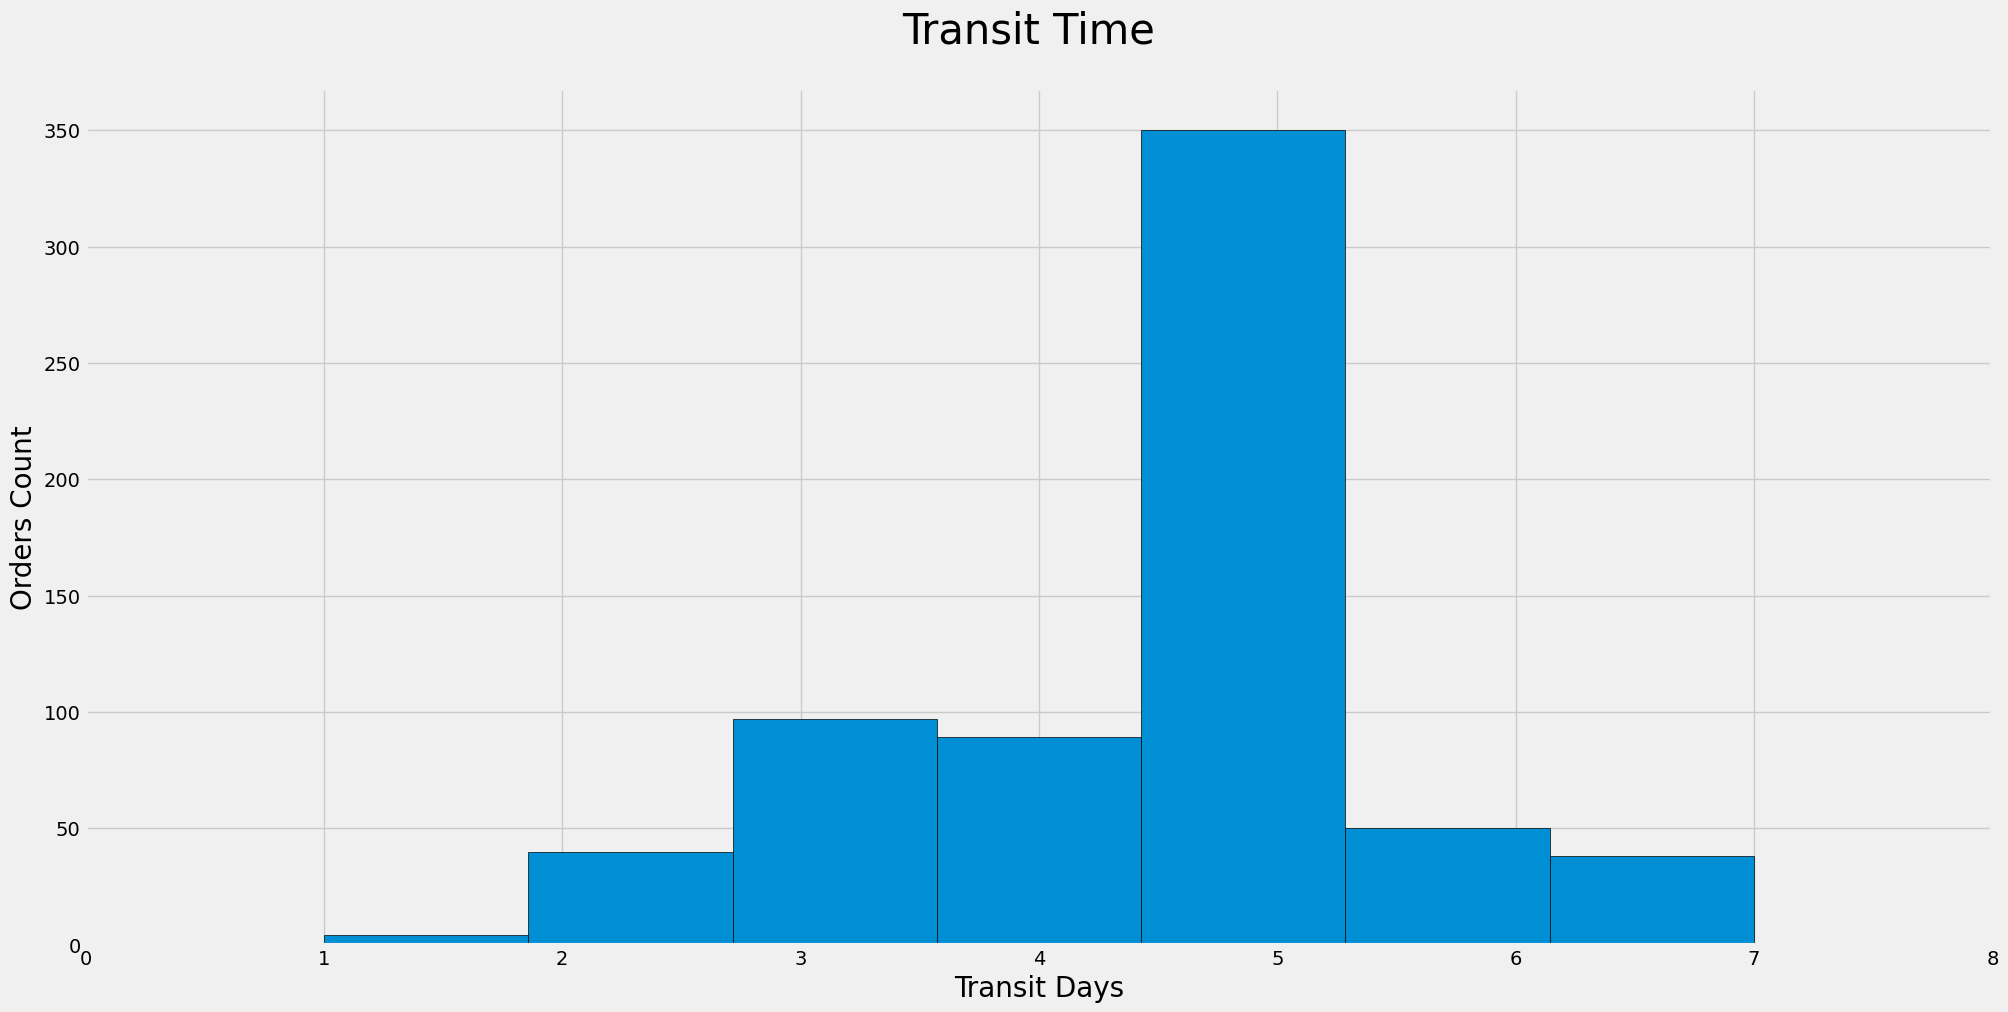

In [282]:
transit_df = pd.merge(left=campaign_data, right=order_process, on='Order ID', how='left')
transit_df['transite_time'] = transit_df['Arrival Scan Date'] - transit_df['On Truck Scan Date']

transit_time = transit_df['transite_time'].dt.days

fig, ax = plt.subplots(figsize=(20,10))
plt.suptitle('Transit Time', fontsize=30)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

plt.hist(x=transit_time, bins=7, edgecolor='black')
plt.ylabel('Orders Count', fontsize=20)
plt.xlabel('Transit Days', fontsize=20)
plt.xlim(0,8)

In [276]:
transit_time.describe()

count   668.00
mean      4.56
std       1.21
min       1.00
25%       4.00
50%       5.00
75%       5.00
max       7.00
Name: transite_time, dtype: float64

In [284]:
transit_df['end_to_end'] = transit_df['Arrival Scan Date'] - transit_df['Order Date']

In [286]:
transit_df.describe()

,Arrival Scan Date,Row ID,Order Date,On Truck Scan Date,total_time_in_warehause,transite_time,end_to_end
count,668,668.00,668,668,668,668,668
mean,2019-10-17 23:19:02.514970112,"4,895.90",2019-10-07 02:02:52.455089920,2019-10-13 09:50:39.520958208,6 days 07:47:47.065868263,4 days 13:28:22.994011976,10 days 21:16:10.059880239
min,2019-05-03 00:00:00,1.00,2019-04-19 00:00:00,2019-04-29 00:00:00,0 days 00:00:00,1 days 00:00:00,3 days 00:00:00
25%,2019-09-09 00:00:00,"2,170.75",2019-08-27 00:00:00,2019-09-04 00:00:00,5 days 00:00:00,4 days 00:00:00,9 days 00:00:00
50%,2019-10-28 00:00:00,"4,949.00",2019-10-15 00:00:00,2019-10-23 00:00:00,7 days 00:00:00,5 days 00:00:00,12 days 00:00:00
75%,2019-12-16 00:00:00,"7,522.25",2019-12-05 00:00:00,2019-12-11 00:00:00,8 days 00:00:00,5 days 00:00:00,13 days 00:00:00
max,2020-05-15 00:00:00,"9,987.00",2020-05-11 00:00:00,2020-05-13 00:00:00,12 days 00:00:00,7 days 00:00:00,17 days 00:00:00
std,NaN,"2,989.51",NaN,NaN,2 days 13:49:37.585534533,1 days 05:00:33.077887896,2 days 21:04:34.269950730


(0.0, 20.0)

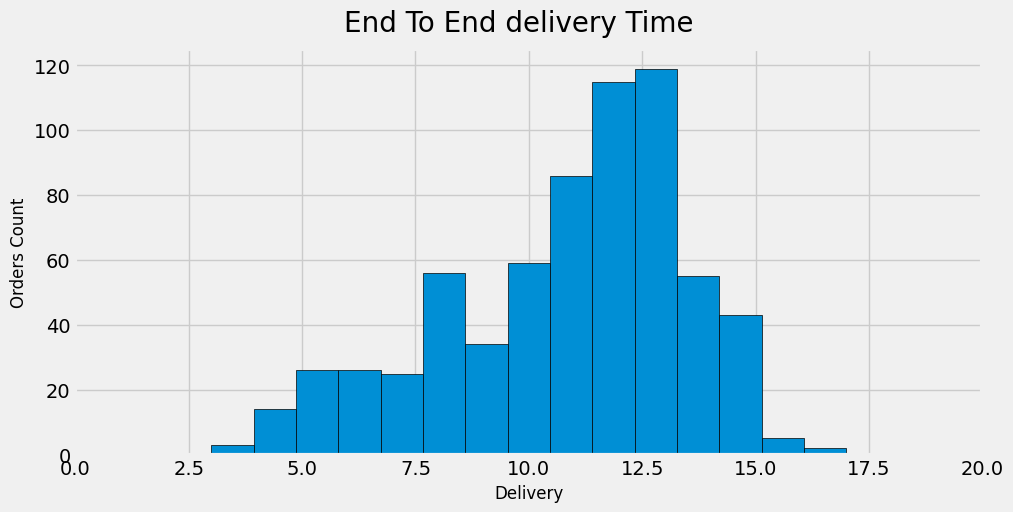

In [355]:
end_to_end = transit_df['end_to_end'].dt.days

fig, ax = plt.subplots(figsize=(10,5))
plt.suptitle('End To End delivery Time', fontsize=20)
fig.tight_layout()
plt.subplots_adjust(hspace=.5, wspace=.2, top=.9)

plt.hist(x=end_to_end, bins=15, edgecolor='black')
plt.ylabel('Orders Count', fontsize=12)
plt.xlabel('Delivery', fontsize=12)
plt.xlim(0,20)

In [309]:
end_to_end.describe()

count   668.00
mean     10.89
std       2.88
min       3.00
25%       9.00
50%      12.00
75%      13.00
max      17.00
Name: end_to_end, dtype: float64

In [335]:
order_process['order_day'] = order_process['Order Date'].dt.day_name()
all_weekend_orders = order_process[(order_process['order_day'] == 'Sunday') | (order_process['order_day'] == 'Saturday')]
all_weekday_orders = order_process[(order_process['order_day'] != 'Sunday') & (order_process['order_day'] != 'Saturday')]

weeend_backlog = round((len(all_weekend_orders)/len(order_process))*100, 2)
weeend_backlog

15.56

In [337]:
# On time processing  
proccessed_within_2days = processing_df[processing_df['processing_time'].dt.days <= 2]
ontime_processed_orders = round(len(proccessed_within_2days)/len(processing_df)*100, 2)
ontime_processed_orders

20.33